# 03 Check WLASL300 Keypoint Output

## Purpose

This notebook validates the extracted WLASL300 MediaPipe keypoint files before training.

## What this notebook checks

- Whether expected `.npy` files exist
- Whether every file has the correct shape `(60, 258)`
- Whether any file has too many zeros
- Class distribution after keypoint extraction
- Final clean training index

## Main output

```text
data/processed/ASL/WLASL300/wlasl300_clean_keypoint_index.csv
```

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Set paths and load WLASL300 video index

In [3]:
PROJECT_ROOT = Path("E:/Be_My_Ear")

DATASET_NAME = "WLASL300"
PREFIX = "wlasl300"

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / DATASET_NAME
KEYPOINT_DIR = BASE_DIR / "keypoints"

VIDEO_INDEX_FILE = BASE_DIR / f"{PREFIX}_video_index.csv"
KEYPOINT_INDEX_FILE = BASE_DIR / f"{PREFIX}_keypoint_index.csv"
CLEAN_INDEX_FILE = BASE_DIR / f"{PREFIX}_clean_keypoint_index.csv"

video_df = pd.read_csv(VIDEO_INDEX_FILE)

print("Dataset:", DATASET_NAME)
print("Videos in usable index:", len(video_df))
print("Classes:", video_df["label_id"].nunique())
print("Extracted .npy files:", len(list(KEYPOINT_DIR.glob("*.npy"))))

Dataset: WLASL300
Videos in usable index: 2660
Classes: 300
Extracted .npy files: 2660


## 2. Rebuild keypoint index from actual `.npy` files

In [4]:
records = []

for _, row in video_df.iterrows():
    keypoint_path = KEYPOINT_DIR / f"{row['video_id']}.npy"

    if keypoint_path.exists():
        records.append({
            "video_id": row["video_id"],
            "gloss": row["gloss"],
            "label_id": int(row["label_id"]),
            "original_class_id": int(row["original_class_id"]),
            "video_path": row["video_path"],
            "keypoint_path": str(keypoint_path)
        })

keypoint_df = pd.DataFrame(records)
keypoint_df.to_csv(KEYPOINT_INDEX_FILE, index=False)

print("Saved keypoint index to:", KEYPOINT_INDEX_FILE)
print("Keypoint samples:", len(keypoint_df))
print("Classes:", keypoint_df["label_id"].nunique())

keypoint_df.head()

Saved keypoint index to: E:\Be_My_Ear\data\processed\ASL\WLASL300\wlasl300_keypoint_index.csv
Keypoint samples: 2660
Classes: 300


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path
0,65096,arrive,10,182,E:\Be_My_Ear\data\raw\ASL\videos\65096.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...
1,65639,environment,107,279,E:\Be_My_Ear\data\raw\ASL\videos\65639.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...
2,10112,chat,53,191,E:\Be_My_Ear\data\raw\ASL\videos\10112.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...
3,55348,student,253,247,E:\Be_My_Ear\data\raw\ASL\videos\55348.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...
4,65092,argue,9,258,E:\Be_My_Ear\data\raw\ASL\videos\65092.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...


## 3. Check missing keypoint files

In [5]:
expected_ids = set(video_df["video_id"].astype(str))
actual_ids = set([p.stem for p in KEYPOINT_DIR.glob("*.npy")])

missing_keypoints = expected_ids - actual_ids

print("Missing keypoint files:", len(missing_keypoints))
list(missing_keypoints)[:20]

Missing keypoint files: 0


[]

## 4. Check file shapes and zero ratios

In [6]:
shape_records = []

for _, row in keypoint_df.iterrows():
    arr = np.load(row["keypoint_path"])

    shape_records.append({
        "video_id": row["video_id"],
        "gloss": row["gloss"],
        "label_id": row["label_id"],
        "shape": arr.shape,
        "num_frames": arr.shape[0],
        "num_features": arr.shape[1] if len(arr.shape) == 2 else None,
        "zero_ratio": float(np.mean(arr == 0))
    })

shape_df = pd.DataFrame(shape_records)

print("Unique shapes:")
print(shape_df["shape"].value_counts())

bad_shapes = shape_df[
    (shape_df["num_frames"] != 60) |
    (shape_df["num_features"] != 258)
]

print("\nBad shape files:", len(bad_shapes))
print("\nZero ratio summary:")
print(shape_df["zero_ratio"].describe())

shape_df.sort_values("zero_ratio", ascending=False).head(20)

Unique shapes:
shape
(60, 258)    2660
Name: count, dtype: int64

Bad shape files: 0

Zero ratio summary:
count    2660.000000
mean        0.237295
std         0.113152
min         0.000000
25%         0.159109
50%         0.256395
75%         0.325969
max         0.501357
Name: zero_ratio, dtype: float64


,video_id,gloss,label_id,shape,num_frames,num_features,zero_ratio
2648,63237,who,285,"(60, 258)",60,258,0.501357
2233,63236,who,285,"(60, 258)",60,258,0.488760
246,31901,know,166,"(60, 258)",60,258,0.488760
882,21209,father,112,"(60, 258)",60,258,0.472481
273,62503,water,280,"(60, 258)",60,258,0.468411
2133,6474,black,30,"(60, 258)",60,258,0.468411
15,10895,city,59,"(60, 258)",60,258,0.464341
1601,63280,why,286,"(60, 258)",60,258,0.459884
390,10703,christmas,58,"(60, 258)",60,258,0.459884
326,41447,past,210,"(60, 258)",60,258,0.451744


## 5. Create clean WLASL300 training index

In [7]:
valid_ids = set(
    shape_df[
        (shape_df["num_frames"] == 60) &
        (shape_df["num_features"] == 258) &
        (shape_df["zero_ratio"] < 0.95)
    ]["video_id"].astype(str)
)

clean_df = keypoint_df[keypoint_df["video_id"].astype(str).isin(valid_ids)].copy()

zero_lookup = shape_df.set_index(shape_df["video_id"].astype(str))["zero_ratio"].to_dict()
clean_df["zero_ratio"] = clean_df["video_id"].astype(str).map(zero_lookup)

clean_df.to_csv(CLEAN_INDEX_FILE, index=False)

print("Saved clean index to:", CLEAN_INDEX_FILE)
print("Clean samples:", len(clean_df))
print("Clean classes:", clean_df["label_id"].nunique())

clean_df.head()

Saved clean index to: E:\Be_My_Ear\data\processed\ASL\WLASL300\wlasl300_clean_keypoint_index.csv
Clean samples: 2660
Clean classes: 300


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,65096,arrive,10,182,E:\Be_My_Ear\data\raw\ASL\videos\65096.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.236047
1,65639,environment,107,279,E:\Be_My_Ear\data\raw\ASL\videos\65639.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.227907
2,10112,chat,53,191,E:\Be_My_Ear\data\raw\ASL\videos\10112.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.028876
3,55348,student,253,247,E:\Be_My_Ear\data\raw\ASL\videos\55348.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.297093
4,65092,argue,9,258,E:\Be_My_Ear\data\raw\ASL\videos\65092.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.244186


## 6. Review class distribution after cleaning

In [8]:
class_counts = clean_df["gloss"].value_counts()

print("Class distribution after cleaning")
print("---------------------------------")
print("Classes:", len(class_counts))
print("Minimum samples per class:", class_counts.min())
print("Maximum samples per class:", class_counts.max())
print("Average samples per class:", round(class_counts.mean(), 2))

class_counts.head(30)

Class distribution after cleaning
---------------------------------
Classes: 300
Minimum samples per class: 5
Maximum samples per class: 16
Average samples per class: 8.87


gloss
before          16
cool            16
thin            16
go              15
drink           15
help            14
cousin          14
computer        14
who             14
candy           13
trade           13
bed             13
accident        13
thanksgiving    13
tall            13
bowling         13
short           13
last            12
pizza           12
change          12
basketball      12
cold            12
dark            12
what            12
shirt           12
corn            12
call            12
yes             12
later           12
man             12
Name: count, dtype: int64

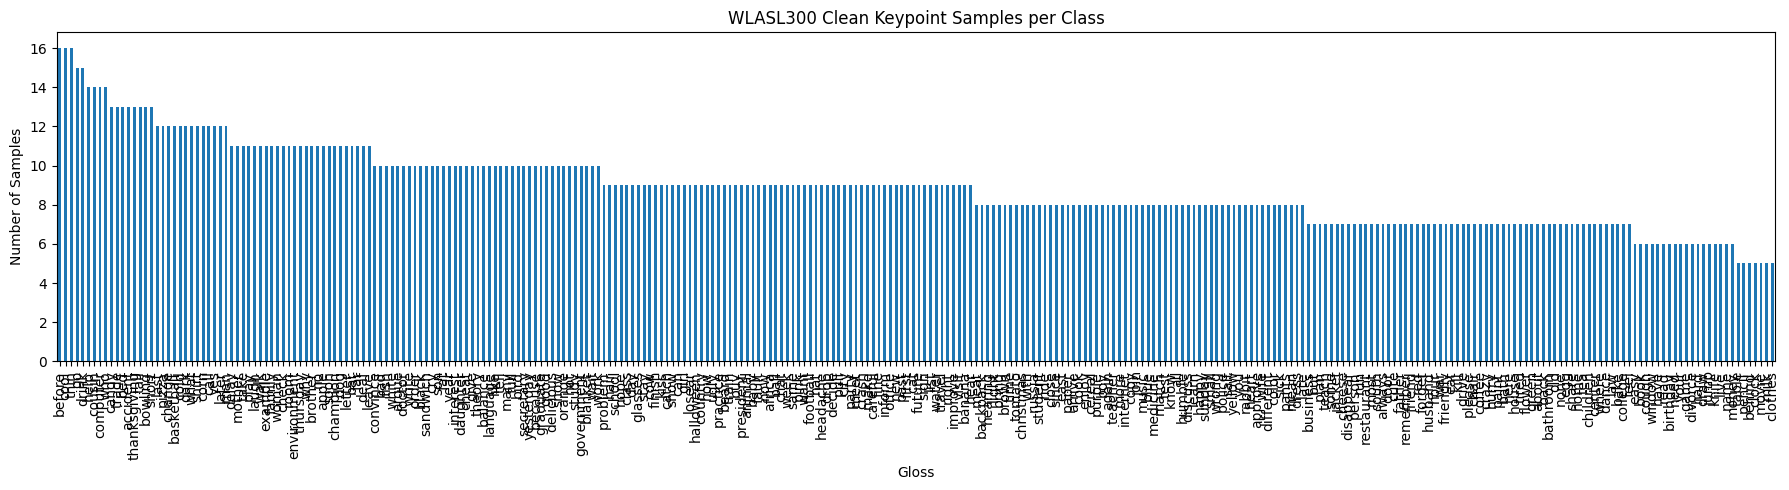

In [9]:
plt.figure(figsize=(18, 5))
class_counts.plot(kind="bar")
plt.title("WLASL300 Clean Keypoint Samples per Class")
plt.xlabel("Gloss")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Final summary

After this notebook, continue with:

```text
04_train_wlasl300_bigru_attention.ipynb
```